# Enterprise Data Architecture & Reconciliation

**Completed submission notebook** for the supplied FinTech financial audit capstone.

This notebook implements the four required technical areas: advanced SQL, vectorized Regex parsing, temporal reconciliation with forward-fill, and the CFO dashboard.

## Phase 1 — Advanced SQL: latest Active users
Use a SQL window function to select the most recent historical record for each user, then retain only users whose latest status is `Active`.

In [1]:
import sys
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'docs' else Path.cwd()
src = ROOT / 'src'
sys.path.insert(0, str(src))
import run_pipeline as pipeline

df_active_users = pipeline.extract_active_users()
df_active_users.head()

,user_id,name,status,updated_at
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00


## Phase 2 — Regex & unstructured data wrangling
The raw source contains a header plus 100,000 log records. ERROR records are excluded, then Date, User ID, Product ID and Euro Value are extracted with vectorized `str.extract()` operations.

In [2]:
extracted_data, parsing_audit = pipeline.parse_server_logs()
print(parsing_audit.to_string(index=False))
extracted_data.head()

                               metric  value
                         raw_log_rows 100000
                  error_rows_filtered   5098
                       non_error_rows  94902
      fully_parsed_valid_transactions  94902
non_error_unparseable_or_invalid_rows      0


,Date,User_ID,Product_ID,Euro_Value
0,2023-03-15,U-19484,PRD-874,3404.44
1,2023-05-09,U-18932,PRD-905,3406.21
2,2023-10-21,U-15882,PRD-284,164.08
3,2023-01-10,U-22781,PRD-665,26.8
4,2023-05-23,U-13348,PRD-589,4964.77


## Phase 3 — Financial reconciliation & temporal joins
Missing EUR/USD source values are forward-filled before joining on the exact calendar date. The transaction table is then left-joined to the latest Active users so transaction loss remains auditable.

In [3]:
rates = pipeline.prepare_exchange_rates()
df_final, monthly_revenue, top5_customers, reconciliation = pipeline.reconcile(
    df_active_users, extracted_data, rates
)
print(reconciliation.to_string(index=False))
df_final.head()

                                       metric  value
                    valid_parsed_transactions  94902
              transactions_with_exchange_rate  94902
           transactions_without_exchange_rate      0
   transactions_matched_to_latest_active_user  53899
transactions_without_latest_active_user_match  41003
                        final_reconciled_rows  94902
                         duplicate_final_rows      0


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD_Filled,user_id,name,status,USD_Revenue,Month,Active_User_Match
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,U-19484,User_U-19484,Active,4011.220772,2023-03,True
1,2023-05-09,U-18932,PRD-905,3406.21,1.104983,<NA>,NaN,NaN,3763.802674,2023-05,False
2,2023-10-21,U-15882,PRD-284,164.08,1.075350,U-15882,User_U-15882,Active,176.44342,2023-10,True
3,2023-01-10,U-22781,PRD-665,26.8,1.127128,U-22781,User_U-22781,Active,30.20703,2023-01,True
4,2023-05-23,U-13348,PRD-589,4964.77,1.019626,<NA>,NaN,NaN,5062.207773,2023-05,False


## Phase 4 — Aggregation & CFO dashboard
The required views are Total USD Revenue by Month and Top 5 Most Valuable Customers.

In [4]:
monthly_revenue.to_string(index=False), top5_customers.to_string(index=False)

('  Month      USD_Revenue\n2023-01  22237617.955632\n2023-02   19914332.36992\n2023-03  21929445.445189\n2023-04  21226582.083788\n2023-05  22244729.572996\n2023-06  21431394.278947\n2023-07  22200965.370969\n2023-08  22515166.511249\n2023-09  21560157.236066\n2023-10  21840122.186244\n2023-11  22140617.871285\n2023-12  22000720.752135',
 'User_ID         name   USD_Revenue\nU-06582 User_U-06582  40050.988262\nU-23313 User_U-23313  39555.806629\nU-03805 User_U-03805  39529.945085\nU-20018 User_U-20018  38649.965242\nU-06489 User_U-06489  38629.142146')

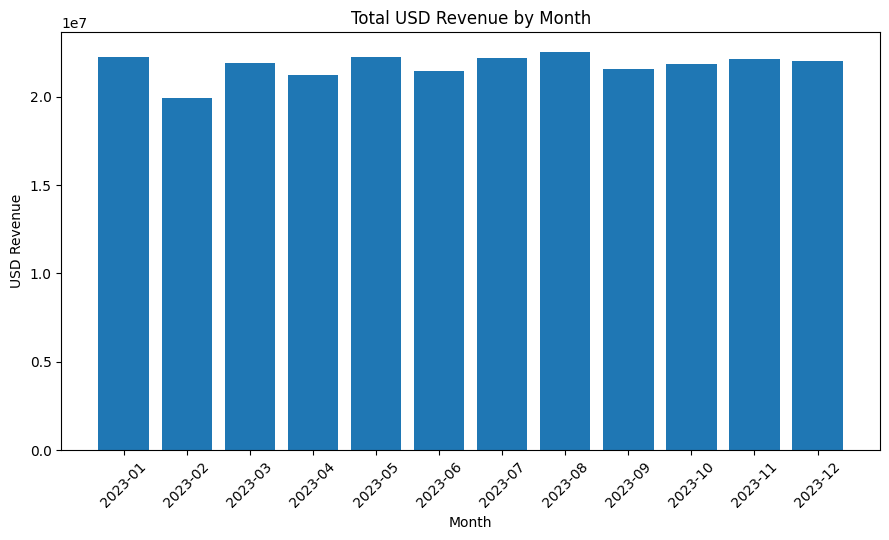

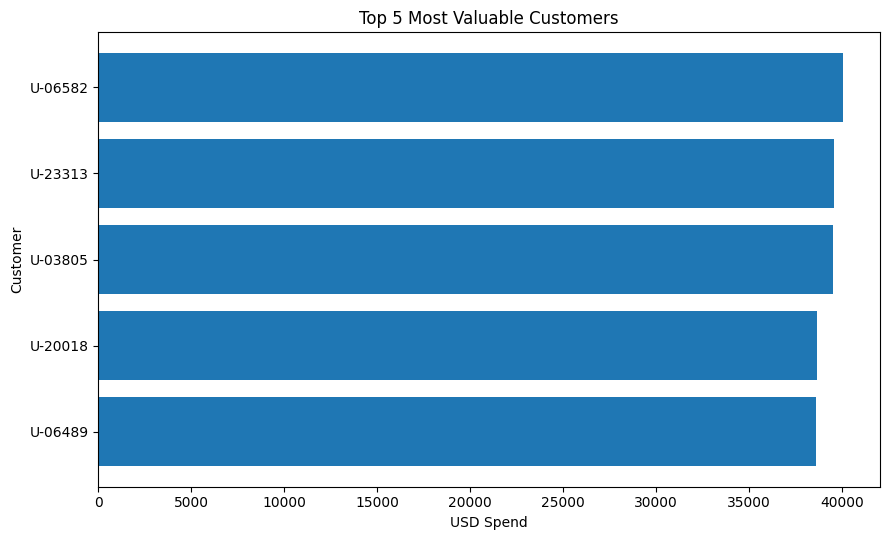

In [5]:
# Standalone charts (one plot per figure)
fig1, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.bar(monthly_revenue['Month'], monthly_revenue['USD_Revenue'])
ax1.set_title('Total USD Revenue by Month')
ax1.set_xlabel('Month')
ax1.set_ylabel('USD Revenue')
ax1.tick_params(axis='x', rotation=45)
fig1.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 5.5))
ax2.barh(top5_customers['User_ID'].astype(str).iloc[::-1], top5_customers['USD_Revenue'].iloc[::-1])
ax2.set_title('Top 5 Most Valuable Customers')
ax2.set_xlabel('USD Spend')
ax2.set_ylabel('Customer')
fig2.tight_layout()
plt.show()

## Final validation
All output checks are computed from the actual supplied files. No synthetic transaction values are used in project results.

In [6]:
quality = pd.DataFrame({
    'check': [
        'active_user_id_unique',
        'exchange_rate_missing_after_ffill',
        'final_missing_date',
        'final_missing_user_id',
        'final_missing_product_id',
        'final_missing_euro_value',
        'final_missing_usd_revenue',
        'final_duplicate_rows',
    ],
    'result': [
        bool(df_active_users['user_id'].is_unique),
        int(rates['EUR_to_USD_Filled'].isna().sum()),
        int(df_final['Date'].isna().sum()),
        int(df_final['User_ID'].isna().sum()),
        int(df_final['Product_ID'].isna().sum()),
        int(df_final['Euro_Value'].isna().sum()),
        int(df_final['USD_Revenue'].isna().sum()),
        int(df_final.duplicated().sum()),
    ]
})
quality

,check,result
0,active_user_id_unique,True
1,exchange_rate_missing_after_ffill,0
2,final_missing_date,0
3,final_missing_user_id,0
4,final_missing_product_id,0
5,final_missing_euro_value,0
6,final_missing_usd_revenue,0
7,final_duplicate_rows,0


## Final headline metrics

- Raw logs: **100,000**
- ERROR rows filtered: **5,098**
- Valid transactions: **94,902**
- Latest Active users: **14,183**
- Active-user matched transactions: **53,899**
- Total USD revenue: **$261,241,851.63**
- Duplicate final rows: **0**
- Missing exchange rates after forward-fill: **0**
